In [18]:
# Does not need to be run again, but here is the code that was used to download the data from the original source.
#
# import os
# import urllib.request

# DATA_DIR = "data"
# BASE_URL = "https://raw.githubusercontent.com/fivethirtyeight/russian-troll-tweets/master"

# os.makedirs(DATA_DIR, exist_ok=True)

# for i in range(1, 13):
#     filename = f"IRAhandle_tweets_{i}.csv"
#     local_path = os.path.join(DATA_DIR, filename)
#     if os.path.exists(local_path):
#         print(f"already have {filename}")
#         continue
#     print(f"downloading {filename}...")
#     urllib.request.urlretrieve(f"{BASE_URL}/{filename}", local_path)

# print("done")

In [19]:
#I rewrote this logic so that we do not need to rescrape each time. 
#It should work as long as you are working in the proper directory

import pandas as pd

frames = []
for i in range(1, 13):
        frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))

df = pd.concat(frames, ignore_index=True)
df.head()

/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_25382/992374803.py:8: DtypeWarning: Columns (0,15,20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))
/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_25382/992374803.py:8: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))
/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_25382/992374803.py:8: DtypeWarning: Columns (10,20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))


,external_author_id,author,content,region,language,publish_date,harvested_date,following,followers,updates,...,account_type,retweet,account_category,new_june_2018,alt_external_id,tweet_id,article_url,tco1_step1,tco2_step1,tco3_step1
0,906000000000000000,10_GOP,"""We have a sitting Democrat US Senator on tria...",Unknown,English,10/1/2017 19:58,10/1/2017 19:59,1052,9636,253,...,Right,0,RightTroll,0,905874659358453760,914580356430536707,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/914580356430...,NaN,NaN
1,906000000000000000,10_GOP,Marshawn Lynch arrives to game in anti-Trump s...,Unknown,English,10/1/2017 22:43,10/1/2017 22:43,1054,9637,254,...,Right,0,RightTroll,0,905874659358453760,914621840496189440,http://twitter.com/905874659358453760/statuses...,https://twitter.com/damienwoody/status/9145685...,NaN,NaN
2,906000000000000000,10_GOP,Daughter of fallen Navy Sailor delivers powerf...,Unknown,English,10/1/2017 22:50,10/1/2017 22:51,1054,9637,255,...,Right,1,RightTroll,0,905874659358453760,914623490375979008,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/913231923715...,NaN,NaN
3,906000000000000000,10_GOP,JUST IN: President Trump dedicates Presidents ...,Unknown,English,10/1/2017 23:52,10/1/2017 23:52,1062,9642,256,...,Right,0,RightTroll,0,905874659358453760,914639143690555392,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/914639143690...,NaN,NaN
4,906000000000000000,10_GOP,"19,000 RESPECTING our National Anthem! #StandF...",Unknown,English,10/1/2017 2:13,10/1/2017 2:13,1050,9645,246,...,Right,1,RightTroll,0,905874659358453760,914312219952861184,http://twitter.com/905874659358453760/statuses...,https://twitter.com/realDonaldTrump/status/914...,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
 15  alt_external_id     object
 16  tweet_id            int64 
 17  article_url         object
 18  tco1_step1          object
 19  tco2_step1          object
 20  tco3_step1          object
dtypes: int64(6), object(15)
memory usage: 468.7+ MB


In [21]:
cleaned_df = df.drop(columns=["tweet_id", "alt_external_id", "article_url", "tco1_step1", "tco2_step1", "tco3_step1"])

In [22]:
cleaned_df["post_type"].head()

0        NaN
1        NaN
2    RETWEET
3        NaN
4    RETWEET
Name: post_type, dtype: object

In [23]:
cleaned_df["post_type"].groupby(cleaned_df["post_type"]).count()

post_type
QUOTE_TWEET      39938
RETWEET        1239753
Name: post_type, dtype: int64

In [24]:
cleaned_df["region"].groupby(cleaned_df["region"]).count()

region
Afghanistan                     3318
Austria                            1
Azerbaijan                     94916
Belarus                        27335
Canada                           608
Czech Republic                     7
Denmark                            1
Egypt                            232
Estonia                            1
Finland                           20
France                           942
Germany                        27178
Greece                            81
Hong Kong                          3
India                             22
Iran, Islamic Republic of        541
Iraq                           11117
Israel                          3604
Italy                          13474
Japan                            108
Latvia                             7
Malaysia                        4932
Mexico                            41
Russian Federation             37052
Samoa                             32
Saudi Arabia                      55
Serbia                         

In [25]:
cleaned_df.replace({"post_type": {None: "TWEET"}}, inplace=True)

In [26]:
cleaned_df["post_type"].head()

0      TWEET
1      TWEET
2    RETWEET
3      TWEET
4    RETWEET
Name: post_type, dtype: object

In [27]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
dtypes: int64(5), object(10)
memory usage: 334.8+ MB


In [28]:
cleaned_df["external_author_id"] = cleaned_df["external_author_id"].astype(str) 
cleaned_df["author"] = cleaned_df["author"].astype(str) 
cleaned_df["content"] = cleaned_df["content"].astype(str) 
cleaned_df["region"] = cleaned_df["region"].astype(str)
cleaned_df["language"] = cleaned_df["language"].astype(str)
cleaned_df["account_category"] = cleaned_df["account_category"].astype(str)

In [29]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
dtypes: int64(5), object(10)
memory usage: 334.8+ MB


In [30]:
cleaned_df["publish_date"] = pd.to_datetime(cleaned_df["publish_date"], format="mixed", errors="coerce")
min_date = cleaned_df["publish_date"].min()
max_date = cleaned_df["publish_date"].max()
cleaned_df["publish_date"] = -1 + 2 * (cleaned_df["publish_date"] - min_date) / (max_date - min_date)
cleaned_df["publish_date"].describe()

count    2.925313e+06
mean     4.230922e-01
std      2.306454e-01
min     -1.000000e+00
25%      2.160120e-01
50%      4.615388e-01
75%      6.104632e-01
max      1.000000e+00
Name: publish_date, dtype: float64

In [78]:
count = (cleaned_df["publish_date"] >= 0).astype(int)
count.value_counts()

publish_date
1    2869053
0      56260
Name: count, dtype: int64

In [31]:
import nltk
nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
sia.polarity_scores("TRUMP 2020!!! Make America Great Again!")

{'neg': 0.0, 'neu': 0.487, 'pos': 0.513, 'compound': 0.7405}

In [ ]:
import re

english_df = cleaned_df[cleaned_df["language"] == "English"].copy()
english_df = english_df.sample(frac=0.25, random_state=67).copy()

_rt_prefix = re.compile(r"^RT @\w+:\s*")
_url = re.compile(r"https?://\S+|www\.\S+")

def clean_tweet(text):
    text = _rt_prefix.sub("", text)
    text = _url.sub("", text)
    return text.strip()

english_df["content_clean"] = english_df["content"].map(clean_tweet)
print(f"English tweets (25% sample): {len(english_df):,}")
english_df[["content", "content_clean"]].head()

English tweets (25% sample): 526,316


,content,content_clean
569339,'SULLY' Tops 'SNOWDEN' at Box Office... https:...,'SULLY' Tops 'SNOWDEN' at Box Office...
1530127,#ChristmasAftermath Accepting new Googloid Sma...,#ChristmasAftermath Accepting new Googloid Sma...
2424637,"#TopNews Six killed, seven injured when SUV ch...","#TopNews Six killed, seven injured when SUV ch..."
2519178,"Awaiting Hague court verdict, Filipinos hope t...","Awaiting Hague court verdict, Filipinos hope t..."
2242375,When bae starts using ur slang,When bae starts using ur slang


In [33]:
from tqdm.auto import tqdm
tqdm.pandas(desc="VADER")

scores = english_df["content_clean"].progress_map(sia.polarity_scores)
scores_df = pd.DataFrame(scores.tolist(), index=english_df.index)
scores_df.columns = ["sent_neg", "sent_neu", "sent_pos", "sent_compound"]

english_df = pd.concat([english_df, scores_df], axis=1)
english_df[["content_clean", "sent_neg", "sent_neu", "sent_pos", "sent_compound"]].head()

VADER:   0%|          | 0/526316 [00:00<?, ?it/s]

,content_clean,sent_neg,sent_neu,sent_pos,sent_compound
569339,'SULLY' Tops 'SNOWDEN' at Box Office...,0.000,0.602,0.398,0.5106
1530127,#ChristmasAftermath Accepting new Googloid Sma...,0.086,0.697,0.217,0.4939
2424637,"#TopNews Six killed, seven injured when SUV ch...",0.396,0.604,0.000,-0.8020
2519178,"Awaiting Hague court verdict, Filipinos hope t...",0.000,0.584,0.416,0.7293
2242375,When bae starts using ur slang,0.000,1.000,0.000,0.0000


In [34]:
english_df["sent_compound"].describe()

count    526316.000000
mean         -0.039318
std           0.418601
min          -0.989200
25%          -0.340000
50%           0.000000
75%           0.202300
max           0.999100
Name: sent_compound, dtype: float64

In [35]:
english_df.groupby("account_category")["sent_compound"].agg(["mean", "std", "count"]).sort_values("mean")

,mean,std,count
account_category,,,
NewsFeed,-0.117132,0.390955,149097
RightTroll,-0.051446,0.445839,174986
Fearmonger,-0.018579,0.426153,2648
LeftTroll,0.022699,0.438025,104431
HashtagGamer,0.027599,0.368014,58987
NonEnglish,0.032767,0.409996,6553
Commercial,0.052611,0.320220,27969
Unknown,0.083429,0.418213,1645


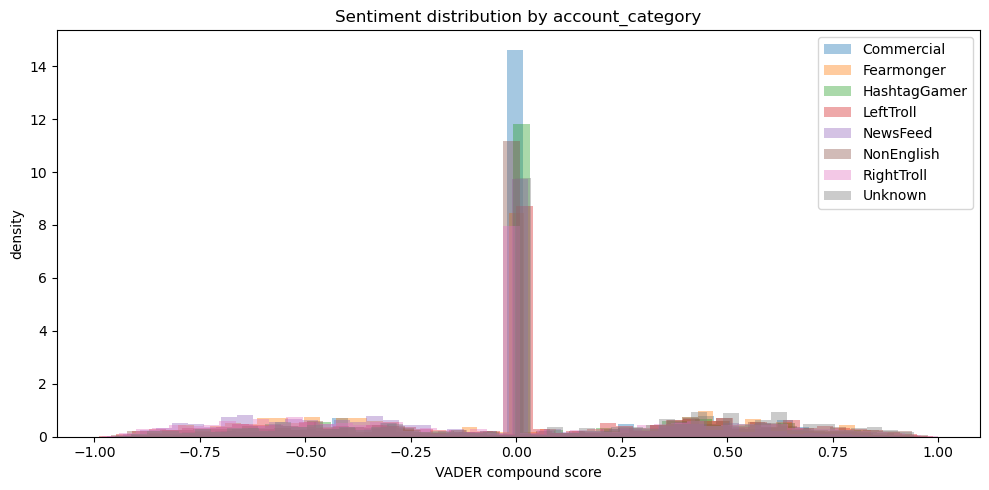

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for cat, grp in english_df.groupby("account_category"):
    grp["sent_compound"].plot(kind="hist", bins=50, alpha=0.4, label=cat, ax=ax, density=True)
ax.set_xlabel("VADER compound score")
ax.set_ylabel("density")
ax.set_title("Sentiment distribution by account_category")
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
for cat in english_df["account_category"].unique():
    sub = english_df[english_df["account_category"] == cat]
    print(f"\n=== {cat} ===")
    print("most positive:", sub.loc[sub["sent_compound"].idxmax(), "content_clean"][:140])
    print("most negative:", sub.loc[sub["sent_compound"].idxmin(), "content_clean"][:140])


=== RightTroll ===
most positive: We win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we w
most negative: ON BRINK OF CIVIL WAR!   Socialism in Venezuela causing death, destruction, suffering, chaos. No food, no order, no hope!   SOCIALISM KILLS!

=== HashtagGamer ===
most positive: Love without regret. Love without fear of rejection. Just love freely.
most negative: So. 2016, a summary: Death. Death. Death. Brexit. Death. Death. President Trump. Death. Death. Christm...Nope. Death.

=== NewsFeed ===
most positive: Join us 11am ET for the best #movies #film #pun #hashtaggames on Twitter! Added bonus: One lucky player wins THIS:
most negative: Home invasion rapist snagged by rape kit testing sentenced to life in prison: Christopher Bennett broke into homes and raped t...  #crime

=== LeftTroll ===
most positive: My goal is to be filthy rich. Rich in knowledge.  Rich in adventure.  Rich in laughter.  Ric

In [38]:
features_df = english_df[[
    "author",
    "publish_date",
    "following",
    "followers",
    "updates",
    "post_type",
    "account_type",
    "retweet",
    "new_june_2018",
    "sent_neg",
    "sent_neu",
    "sent_pos",
    "sent_compound",
    "account_category",
]].copy()

features_df.head()

,author,publish_date,following,followers,updates,post_type,account_type,retweet,new_june_2018,sent_neg,sent_neu,sent_pos,sent_compound,account_category
569339,CHESPLAYSCHESS,0.463937,1062,1475,16151,RETWEET,Right,1,0,0.000,0.602,0.398,0.5106,RightTroll
1530127,KATHIEMRR,0.549556,4422,4228,5378,RETWEET,Hashtager,1,0,0.086,0.697,0.217,0.4939,HashtagGamer
2424637,SCREAMYMONKEY,0.152072,14438,13262,13915,TWEET,news,0,0,0.396,0.604,0.000,-0.8020,NewsFeed
2519178,SPECIALAFFAIR,0.402795,10157,11269,29006,TWEET,news,0,0,0.000,0.584,0.416,0.7293,NewsFeed
2242375,RAVENICHOLSON,-0.012467,95,87,303,TWEET,Left,0,0,0.000,1.000,0.000,0.0000,LeftTroll


In [39]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 526316 entries, 569339 to 629706
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   author            526316 non-null  object 
 1   publish_date      526316 non-null  float64
 2   following         526316 non-null  int64  
 3   followers         526316 non-null  int64  
 4   updates           526316 non-null  int64  
 5   post_type         526316 non-null  object 
 6   account_type      526316 non-null  object 
 7   retweet           526316 non-null  int64  
 8   new_june_2018     526316 non-null  int64  
 9   sent_neg          526316 non-null  float64
 10  sent_neu          526316 non-null  float64
 11  sent_pos          526316 non-null  float64
 12  sent_compound     526316 non-null  float64
 13  account_category  526316 non-null  object 
dtypes: float64(5), int64(5), object(4)
memory usage: 60.2+ MB


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

y = (features_df["publish_date"] >= 0).astype(int)
X = features_df.drop(columns=["publish_date", "author"])
X = pd.get_dummies(X, columns=["post_type", "account_type", "account_category"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=67)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

accuracy: 0.9980
              precision    recall  f1-score   support

           0     0.9703    0.9543    0.9622      2777
           1     0.9988    0.9992    0.9990    102487

    accuracy                         0.9980    105264
   macro avg     0.9846    0.9767    0.9806    105264
weighted avg     0.9980    0.9980    0.9980    105264

